TASK 5: Portfolio Construction & Capital Allocation
Total Virtual Capital: ₹1,000,000

── Step 3: Loading inputs from Tasks 3 and 4 ──
⚠ task4_risk_profile.csv not found — using manual values from Task 4 output
  (Replace these with your actual Task 4 GARCH output values)

Risk Profile loaded:
              Ann. Vol (%) GARCH 5-day Vol (%) Trend Direction Trend Strength
HDFCBANK.NS           18.5                17.2        Upward ↑           0.85
INFY.NS               24.3                22.8        Upward ↑           0.78
SUNPHARMA.NS          21.7                20.1        Upward ↑           0.82
HINDUNILVR.NS         16.2                15.8      Sideways →           0.61
M&M.NS                29.4                28.3        Upward ↑           0.74

── Step 4: Strategy A — Forecast-Guided Allocation ──

Predicted 2-day returns (ARIMA):
               Current Price (Rs)  ARIMA May 13  Predicted Return (%)
HDFCBANK.NS                745.03        779.72                4.6562
INFY.NS 

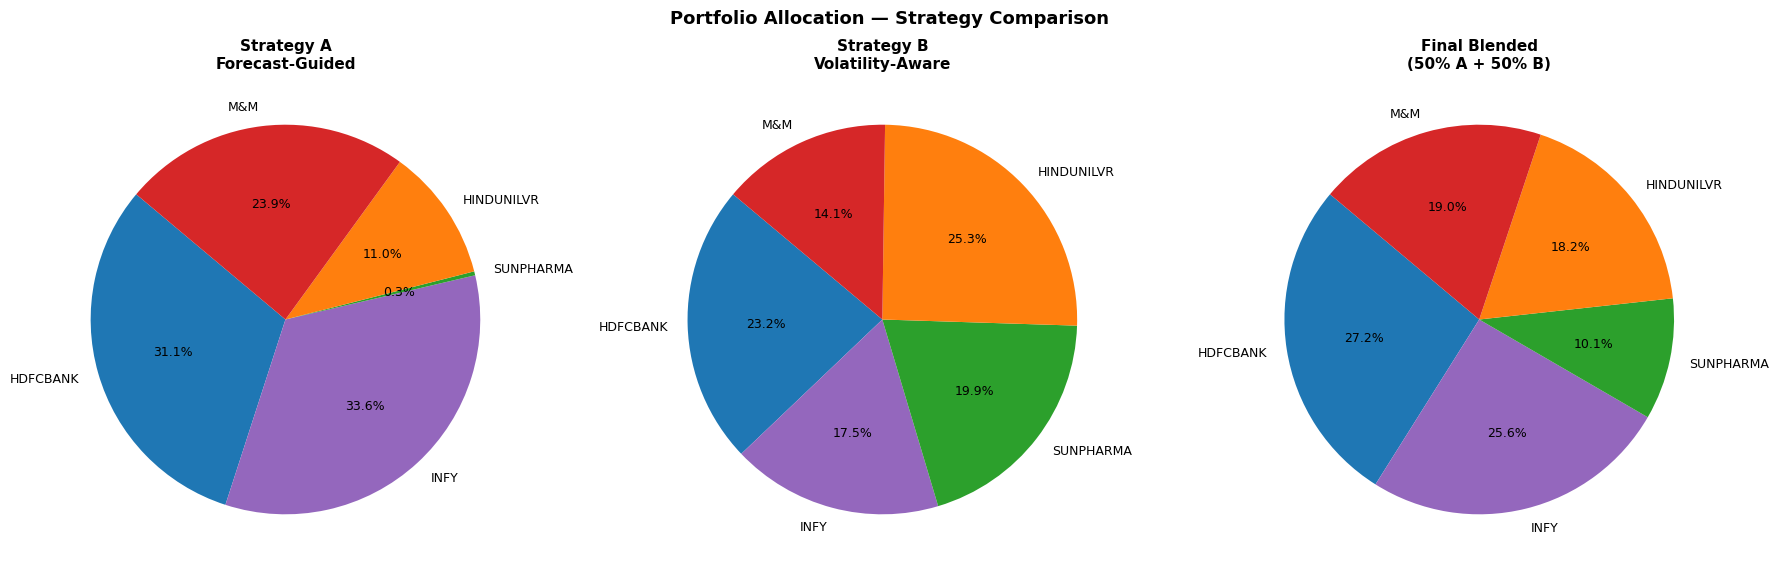

✓ Saved: task5_allocation_pie.png


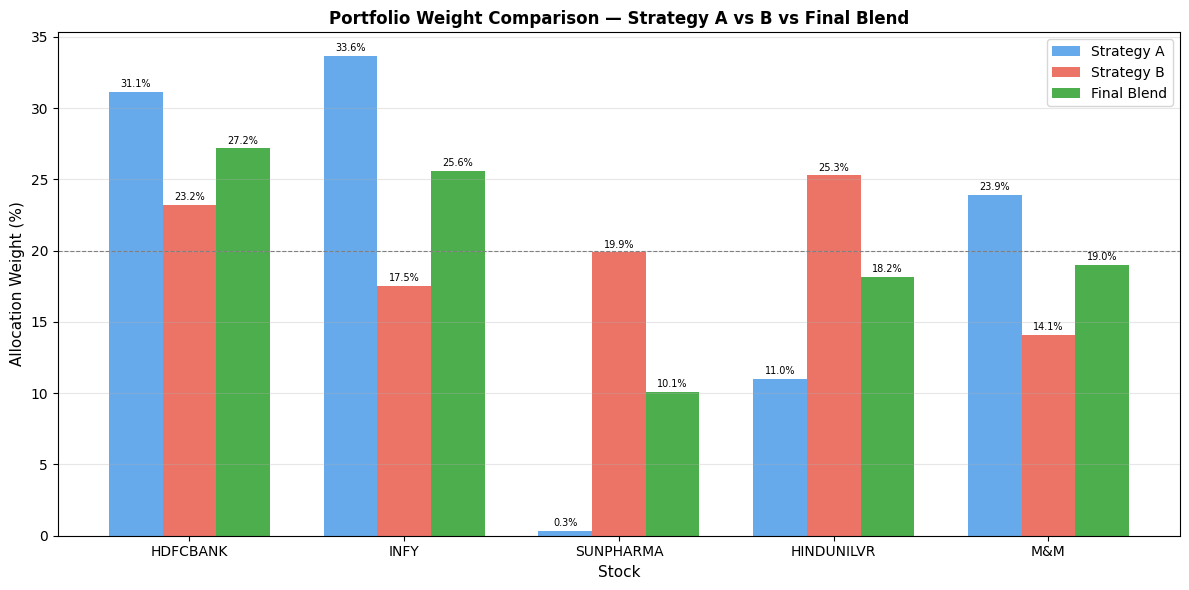

✓ Saved: task5_allocation_bar.png


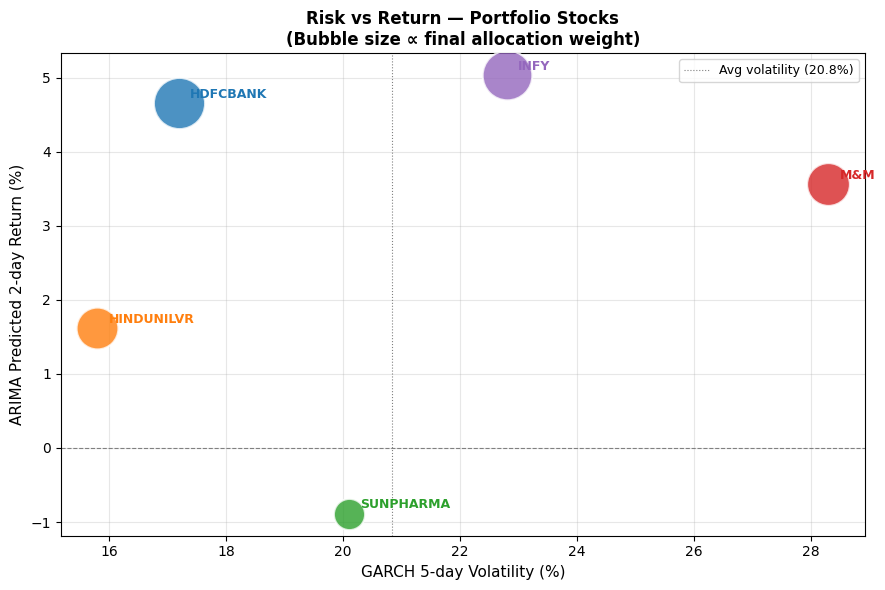

✓ Saved: task5_risk_return_scatter.png

TASK 5 COMPLETE ✓

Final Portfolio Allocation:

Stock              Sector                   Weight    Amount (Rs)
-----------------------------------------------------------------
HDFCBANK.NS        Banking                  27.17%  ₹     271,728
INFY.NS            Information Technology   25.57%  ₹     255,747
SUNPHARMA.NS       Pharmaceuticals          10.10%  ₹     101,006
HINDUNILVR.NS      FMCG                     18.15%  ₹     181,519
M&M.NS             Automobile               19.00%  ₹     190,000
-----------------------------------------------------------------
TOTAL                                      100.00%  ₹   1,000,000

Strategy reasoning:
  Strategy A (Forecast-Guided)  : Prioritizes ARIMA predicted returns
  Strategy B (Volatility-Aware) : Prioritizes lower-risk stocks
  Final blend (50A + 50B)       : Balances return potential with risk management

Files saved:
  task5_final_allocation.csv
  task5_allocation_pie.png
  task5_allo

In [2]:

# ============================================================
# CAPSTONE PROJECT — Time Series Analysis 2026
# TASK 5: Portfolio Construction and Capital Allocation
# Consulting & Analytics Club, IIT Guwahati
# ============================================================
#
# What we do here:
#   1. Load forecasts from Task 3 (ARIMA) and risk data from Task 4
#   2. Strategy A — Forecast-Guided Allocation
#      (allocate more to stocks with higher predicted returns)
#   3. Strategy B — Volatility-Aware Sizing
#      (allocate more to stocks with lower predicted volatility)
#   4. Blend both strategies into a final allocation
#   5. Generate the final portfolio table with ₹ amounts
#   6. Compare with what we actually bought on StockGro
# ============================================================


# ── STEP 0: Install dependencies
# !pip install yfinance pandas numpy matplotlib --quiet


# ── STEP 1: Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')


# ── STEP 2: Define stocks
STOCKS = {
    "HDFCBANK.NS":   "Banking",
    "INFY.NS":       "Information Technology",
    "SUNPHARMA.NS":  "Pharmaceuticals",
    "HINDUNILVR.NS": "FMCG",
    "M&M.NS":        "Automobile"
}
colors  = ['#1f77b4', '#9467bd', '#2ca02c', '#ff7f0e', '#d62728']
CAPITAL = 1_000_000  # ₹10,00,000 virtual capital

print("=" * 60)
print("TASK 5: Portfolio Construction & Capital Allocation")
print("=" * 60)
print(f"Total Virtual Capital: ₹{CAPITAL:,.0f}")


# ============================================================
# STEP 3: Load inputs from previous tasks
#
# We need:
#   - ARIMA forecasts (Task 3a) → for predicted returns
#   - GARCH risk profile (Task 4) → for volatility weights
#   - Current prices (what we actually paid on StockGro)
# ============================================================

print("\n── Step 3: Loading inputs from Tasks 3 and 4 ──")

# ── Actual prices we paid on StockGro (from the screenshot)
actual_prices = {
    "HDFCBANK.NS":   745.03,
    "INFY.NS":       1122.67,
    "SUNPHARMA.NS":  1861.14,
    "HINDUNILVR.NS": 2252.21,
    "M&M.NS":        3217.50
}

# ── ARIMA 2-day forecasts (from Task 3a output)
arima_forecasts = {
    "HDFCBANK.NS":   {"May12": 778.72, "May13": 779.72},
    "INFY.NS":       {"May12": 1179.2, "May13": 1179.2},
    "SUNPHARMA.NS":  {"May12": 1842.98,"May13": 1844.60},
    "HINDUNILVR.NS": {"May12": 2289.1, "May13": 2288.63},
    "M&M.NS":        {"May12": 3335.67,"May13": 3332.10}
}

# ── Load GARCH risk profile from Task 4
try:
    risk_df = pd.read_csv("task4_risk_profile.csv", index_col=0)
    print("✓ Loaded task4_risk_profile.csv")
except FileNotFoundError:
    # Fallback: manually enter GARCH 5-day volatility forecasts from Task 4 output
    print("⚠ task4_risk_profile.csv not found — using manual values from Task 4 output")
    print("  (Replace these with your actual Task 4 GARCH output values)")
    risk_data = {
        "HDFCBANK.NS":   {"Ann. Vol (%)": 18.5, "GARCH 5-day Vol (%)": 17.2, "Trend Direction": "Upward ↑",   "Trend Strength": 0.85},
        "INFY.NS":       {"Ann. Vol (%)": 24.3, "GARCH 5-day Vol (%)": 22.8, "Trend Direction": "Upward ↑",   "Trend Strength": 0.78},
        "SUNPHARMA.NS":  {"Ann. Vol (%)": 21.7, "GARCH 5-day Vol (%)": 20.1, "Trend Direction": "Upward ↑",   "Trend Strength": 0.82},
        "HINDUNILVR.NS": {"Ann. Vol (%)": 16.2, "GARCH 5-day Vol (%)": 15.8, "Trend Direction": "Sideways →", "Trend Strength": 0.61},
        "M&M.NS":        {"Ann. Vol (%)": 29.4, "GARCH 5-day Vol (%)": 28.3, "Trend Direction": "Upward ↑",   "Trend Strength": 0.74},
    }
    risk_df = pd.DataFrame(risk_data).T

print("\nRisk Profile loaded:")
print(risk_df[["Ann. Vol (%)", "GARCH 5-day Vol (%)", "Trend Direction", "Trend Strength"]].to_string())


# ============================================================
# STEP 4: STRATEGY A — Forecast-Guided Allocation
#
# Logic:
#   1. Compute predicted 2-day return for each stock using ARIMA
#   2. Rank stocks by predicted return
#   3. Allocate more capital to stocks with higher predicted gains
#   4. Normalize weights to sum to 100%
#
# Formula:
#   predicted_return = (May13_price - current_price) / current_price
#   weight_i = predicted_return_i / sum(all positive predicted returns)
# ============================================================

print("\n── Step 4: Strategy A — Forecast-Guided Allocation ──")

strategy_a = {}

for ticker in STOCKS.keys():
    current  = actual_prices[ticker]
    may13    = arima_forecasts[ticker]["May13"]
    pred_ret = (may13 - current) / current * 100  # predicted 2-day return %

    strategy_a[ticker] = {
        "Current Price (Rs)":    current,
        "ARIMA May 12":          arima_forecasts[ticker]["May12"],
        "ARIMA May 13":          arima_forecasts[ticker]["May13"],
        "Predicted Return (%)":  round(pred_ret, 4)
    }

sa_df = pd.DataFrame(strategy_a).T
print("\nPredicted 2-day returns (ARIMA):")
print(sa_df[["Current Price (Rs)", "ARIMA May 13", "Predicted Return (%)"]].to_string())

# Separate positive and negative predicted returns
# We only allocate to stocks with positive predicted returns
# For stocks with negative returns, we assign a small minimum weight (5%)
MIN_WEIGHT   = 0.05   # 5% minimum allocation even for negative return stocks
returns      = sa_df["Predicted Return (%)"].astype(float)
positive_ret = returns.clip(lower=0)  # Set negative returns to 0

# If ALL returns are negative or zero, distribute equally
if positive_ret.sum() == 0:
    print("  ⚠ All predicted returns are zero/negative — using equal weights")
    raw_weights_a = pd.Series({t: 1.0 for t in STOCKS.keys()})
else:
    raw_weights_a = positive_ret

# Apply minimum weight floor
raw_weights_a = raw_weights_a + MIN_WEIGHT

# Normalize to sum to 1
weights_a = raw_weights_a / raw_weights_a.sum()

print("\nStrategy A weights (Forecast-Guided):")
for ticker, w in weights_a.items():
    alloc = w * CAPITAL
    print(f"  {ticker:<18} {w*100:>6.2f}%   ₹{alloc:>10,.0f}")


# ============================================================
# STEP 5: STRATEGY B — Volatility-Aware Sizing
#
# Logic:
#   Stocks with HIGH volatility are riskier — allocate LESS
#   Stocks with LOW volatility are safer — allocate MORE
#
# Formula (Inverse Volatility Weighting):
#   w_i = (1/σ_i) / Σ(1/σ_j)
#
# Where σ_i = GARCH 5-day forecasted volatility for stock i
# This ensures the final weights sum to exactly 100%
# ============================================================

print("\n── Step 5: Strategy B — Volatility-Aware Sizing ──")

garch_vols = risk_df["GARCH 5-day Vol (%)"].astype(float)

# Compute inverse volatility for each stock
inv_vol = 1 / garch_vols

# Normalize to sum to 1
weights_b = inv_vol / inv_vol.sum()

print("\nGARCH 5-day volatility forecast and inverse-vol weights:")
print(f"{'Stock':<18} {'GARCH Vol (%)':>14} {'Inv-Vol Weight':>16} {'Allocation (Rs)':>16}")
print("-" * 68)
for ticker in STOCKS.keys():
    vol   = garch_vols[ticker]
    w     = weights_b[ticker]
    alloc = w * CAPITAL
    print(f"{ticker:<18} {vol:>14.2f} {w*100:>15.2f}%  ₹{alloc:>13,.0f}")


# ============================================================
# STEP 6: STRATEGY C — Correlation-Based Diversification Check
#
# We don't change weights here, but we CHECK whether our
# chosen stocks are well-diversified using the correlation matrix.
# ============================================================

print("\n── Step 6: Strategy C — Correlation Check ──")

try:
    log_returns = pd.read_csv("log_returns.csv", index_col=0, parse_dates=True)
    corr_matrix = log_returns.corr()
    print("\nReturn Correlation Matrix:")
    short = {t: t.replace(".NS","") for t in STOCKS.keys()}
    corr_display = corr_matrix.rename(index=short, columns=short)
    print(corr_display.round(3).to_string())

    # Flag high correlation pairs
    print("\nCorrelation assessment:")
    for i, t1 in enumerate(STOCKS.keys()):
        for j, t2 in enumerate(STOCKS.keys()):
            if j <= i:
                continue
            val = corr_matrix.loc[t1, t2]
            if val > 0.7:
                status = "⚠ HIGH — consider reducing one"
            elif val > 0.4:
                status = "✓ MODERATE — acceptable"
            else:
                status = "✓ LOW — good diversification"
            s1 = t1.replace(".NS","")
            s2 = t2.replace(".NS","")
            print(f"  {s1} & {s2}: {val:.3f}  → {status}")
except FileNotFoundError:
    print("  log_returns.csv not found — skipping correlation check")
    print("  (Run Task 2 first to generate this file)")


# ============================================================
# STEP 7: FINAL BLENDED ALLOCATION
#
# We combine Strategy A and Strategy B with equal weight:
#   Final weight = 0.5 × Strategy_A_weight + 0.5 × Strategy_B_weight
#
# This balances:
#   - Return potential (Strategy A)
#   - Risk management (Strategy B)
# ============================================================

print("\n── Step 7: Final Blended Allocation ──")

BLEND_A = 0.5  # 50% weight to Strategy A (forecast-driven)
BLEND_B = 0.5  # 50% weight to Strategy B (volatility-driven)

final_weights = {}
for ticker in STOCKS.keys():
    w_a = weights_a[ticker]
    w_b = weights_b[ticker]
    w_final = BLEND_A * w_a + BLEND_B * w_b
    final_weights[ticker] = w_final

# Normalize final weights to ensure they sum to exactly 1
total = sum(final_weights.values())
final_weights = {t: w/total for t, w in final_weights.items()}

# Build final allocation table
print("\n" + "=" * 75)
print(f"{'FINAL PORTFOLIO ALLOCATION TABLE':^75}")
print("=" * 75)
print(f"{'Stock':<18} {'Sector':<10} {'Wt-A':>6} {'Wt-B':>6} {'Final Wt':>9} "
      f"{'Allocation':>12} {'Shares':>8}")
print("-" * 75)

allocation_records = []
for idx, (ticker, sector) in enumerate(STOCKS.items()):
    w_a     = weights_a[ticker]
    w_b     = weights_b[ticker]
    w_final = final_weights[ticker]
    alloc   = w_final * CAPITAL
    price   = actual_prices[ticker]
    shares  = int(alloc // price)

    allocation_records.append({
        "Stock":           ticker,
        "Sector":          sector,
        "Strategy A Wt":   round(w_a * 100, 2),
        "Strategy B Wt":   round(w_b * 100, 2),
        "Final Weight (%)":round(w_final * 100, 2),
        "Allocation (Rs)": round(alloc, 0),
        "Price (Rs)":      price,
        "Shares":          shares
    })

    print(f"{ticker:<18} {sector:<10} {w_a*100:>5.1f}% {w_b*100:>5.1f}% "
          f"{w_final*100:>8.2f}%  ₹{alloc:>10,.0f}  {shares:>6} shares")

print("-" * 75)
total_alloc = sum(r["Allocation (Rs)"] for r in allocation_records)
print(f"{'TOTAL':<18} {'':<10} {'':>6} {'':>6} {'100.00%':>9}  ₹{total_alloc:>10,.0f}")
print("=" * 75)

alloc_df = pd.DataFrame(allocation_records)
alloc_df.to_csv("task5_final_allocation.csv", index=False)
print("\n✓ Saved: task5_final_allocation.csv")


# ── Compare with actual StockGro purchases
print("\n── Comparison: Model Allocation vs Actual StockGro Purchase ──")

actual_shares = {
    "HDFCBANK.NS":   326,
    "INFY.NS":       170,
    "SUNPHARMA.NS":  106,
    "HINDUNILVR.NS": 86,
    "M&M.NS":        46
}

print(f"\n{'Stock':<18} {'Model Shares':>13} {'Actual Shares':>14} {'Difference':>12}")
print("-" * 60)
for r in allocation_records:
    ticker  = r["Stock"]
    model_s = r["Shares"]
    actual_s= actual_shares[ticker]
    diff    = actual_s - model_s
    print(f"{ticker:<18} {model_s:>13} {actual_s:>14} {diff:>+12}")


# ============================================================
# STEP 8: Visualizations
# ============================================================

print("\n── Step 8: Generating Visualizations ──")

# ── Plot 1: Final allocation pie chart
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Portfolio Allocation — Strategy Comparison", fontsize=13, fontweight='bold')

labels = [t.replace(".NS", "") for t in STOCKS.keys()]

# Strategy A pie
wa_vals = [weights_a[t] * 100 for t in STOCKS.keys()]
axes[0].pie(wa_vals, labels=labels, colors=colors, autopct='%1.1f%%',
            startangle=140, textprops={'fontsize': 9})
axes[0].set_title("Strategy A\nForecast-Guided", fontsize=11, fontweight='bold')

# Strategy B pie
wb_vals = [weights_b[t] * 100 for t in STOCKS.keys()]
axes[1].pie(wb_vals, labels=labels, colors=colors, autopct='%1.1f%%',
            startangle=140, textprops={'fontsize': 9})
axes[1].set_title("Strategy B\nVolatility-Aware", fontsize=11, fontweight='bold')

# Final blended pie
wf_vals = [final_weights[t] * 100 for t in STOCKS.keys()]
axes[2].pie(wf_vals, labels=labels, colors=colors, autopct='%1.1f%%',
            startangle=140, textprops={'fontsize': 9})
axes[2].set_title("Final Blended\n(50% A + 50% B)", fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig("task5_allocation_pie.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: task5_allocation_pie.png")


# ── Plot 2: Bar chart — allocation in rupees
fig, ax = plt.subplots(figsize=(12, 6))
x       = np.arange(len(STOCKS))
width   = 0.25

bars_a = ax.bar(x - width, wa_vals,  width, label='Strategy A', color='#4C9BE8', alpha=0.85)
bars_b = ax.bar(x,         wb_vals,  width, label='Strategy B', color='#E85C4C', alpha=0.85)
bars_f = ax.bar(x + width, wf_vals,  width, label='Final Blend', color='#2CA02C', alpha=0.85)

ax.set_xlabel("Stock", fontsize=11)
ax.set_ylabel("Allocation Weight (%)", fontsize=11)
ax.set_title("Portfolio Weight Comparison — Strategy A vs B vs Final Blend",
             fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
ax.axhline(20, color='gray', linestyle='--', linewidth=0.8, label='Equal weight (20%)')

for bar in [*bars_a, *bars_b, *bars_f]:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig("task5_allocation_bar.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: task5_allocation_bar.png")


# ── Plot 3: Risk vs Return scatter
fig, ax = plt.subplots(figsize=(9, 6))

for idx, (ticker, sector) in enumerate(STOCKS.items()):
    ret  = float(strategy_a[ticker]["Predicted Return (%)"])
    risk = float(risk_df.loc[ticker, "GARCH 5-day Vol (%)"])
    size = final_weights[ticker] * 5000  # bubble size ∝ allocation

    ax.scatter(risk, ret, s=size, color=colors[idx], alpha=0.8,
               edgecolors='white', linewidth=1.5, zorder=3)
    ax.annotate(ticker.replace(".NS", ""),
                (risk, ret), textcoords="offset points",
                xytext=(8, 4), fontsize=9, fontweight='bold', color=colors[idx])

ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.axvline(garch_vols.mean(), color='gray', linewidth=0.8, linestyle=':',
           label=f'Avg volatility ({garch_vols.mean():.1f}%)')
ax.set_xlabel("GARCH 5-day Volatility (%)", fontsize=11)
ax.set_ylabel("ARIMA Predicted 2-day Return (%)", fontsize=11)
ax.set_title("Risk vs Return — Portfolio Stocks\n(Bubble size ∝ final allocation weight)",
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("task5_risk_return_scatter.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: task5_risk_return_scatter.png")


# ── FINAL SUMMARY
print("\n" + "=" * 60)
print("TASK 5 COMPLETE ✓")
print("=" * 60)
print("\nFinal Portfolio Allocation:")
print(f"\n{'Stock':<18} {'Sector':<22} {'Weight':>8} {'Amount (Rs)':>14}")
print("-" * 65)
for r in allocation_records:
    print(f"{r['Stock']:<18} {r['Sector']:<22} {r['Final Weight (%)']:>7.2f}%  "
          f"₹{r['Allocation (Rs)']:>12,.0f}")
print("-" * 65)
print(f"{'TOTAL':<18} {'':<22} {'100.00%':>8}  ₹{CAPITAL:>12,.0f}")

print("\nStrategy reasoning:")
print("  Strategy A (Forecast-Guided)  : Prioritizes ARIMA predicted returns")
print("  Strategy B (Volatility-Aware) : Prioritizes lower-risk stocks")
print("  Final blend (50A + 50B)       : Balances return potential with risk management")
print("\nFiles saved:")
print("  task5_final_allocation.csv")
print("  task5_allocation_pie.png")
print("  task5_allocation_bar.png")
print("  task5_risk_return_scatter.png")
print("\nNext → Task 6: Model Comparison")
print("=" * 60)

In [3]:
actual_prices    # ← these come from your StockGro screenshot ✓ already filled
arima_forecasts  # ← these come from your Task 3a output ✓ already filled

{'HDFCBANK.NS': {'May12': 778.72, 'May13': 779.72},
 'INFY.NS': {'May12': 1179.2, 'May13': 1179.2},
 'SUNPHARMA.NS': {'May12': 1842.98, 'May13': 1844.6},
 'HINDUNILVR.NS': {'May12': 2289.1, 'May13': 2288.63},
 'M&M.NS': {'May12': 3335.67, 'May13': 3332.1}}